In [1]:
library(tidyverse)
require(forcats)
library(RColorBrewer)
library(pheatmap)
library(qvalue)
library(viridis)
# library(dendsort)
# sort_hclust <- function(...) as.hclust(dendsort(as.dendrogram(...)))

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘tibble’ was built under R version 4.3.3”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: viridisLite



In [2]:
dat_all <- read.table("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/GWAS/output_nat/hsc.summary.tsv", 
                      sep = "\t", 
                      header = FALSE, 
                      stringsAsFactors = FALSE)

In [3]:
results <- dat_all 
colnames(results) <- c( "Cluster", "Coefficient", "Coefficient_std_error", "Coefficient_P_value", "Trait")

In [4]:
head(results)

,Cluster,Coefficient,Coefficient_std_error,Coefficient_P_value,Trait
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,Microglia,1.862103e-07,5.654707e-08,0.0004955963,AD2
2,MFOL,4.558329e-08,3.446735e-08,0.0929998005,AD2
3,EC,8.192781e-08,6.356879e-08,0.0987328450,AD2
4,MOL,4.383869e-08,3.839180e-08,0.1267526465,AD2
5,InN_immature_2,1.651976e-08,2.299724e-08,0.2362748774,AD2
6,PC,1.557310e-08,2.761296e-08,0.2863846062,AD2


In [5]:
table(results$Cluster)


      APC_cycling        APC_dorsal       APC_ventral               AST 
               37                37                37                37 
              COP                EC    ExN_immature_1    ExN_immature_2 
               37                37                37                37 
   ExN_immature_3      ExN_mature_1      ExN_mature_2      ExN_mature_3 
               37                37                37                37 
        ExN_naive       ExN_ventral                FP    InN_immature_1 
               37                37                37                37 
   InN_immature_2      InN_mature_1      InN_mature_2         InN_naive 
               37                37                37                37 
    InN_ventral_1     InN_ventral_2     InN_ventral_3               IPC 
               37                37                37                37 
             MFOL         Microglia               MN1               MN2 
               37                37               

In [6]:
table(results$Trait)


          AD          AD2         ADHD          AHD     Allergic          ALS 
          37           37           37           37           37           37 
        ALS2         ALS3         ALS4         ALS5           AN          ANX 
          37           37           37           37           37           37 
         AOA           AR          ASD          ATM       Benign           BP 
          37           37           37           37           37           37 
         CDG         CRPS Encephalitis    Epilespsy          GGE       Height 
          37           37           37           37           37           37 
    Insomnia           IQ          MDD           MS  Neuroticism          OCD 
          37           37           37           37           37           37 
  Parasomnia         PTSD           RA          SCZ          SPA      Tobacco 
          37           37           37           37           37           37 
      Weight 
          37 

In [8]:
traits <- c("AD", "ADHD", "AHD", "ALS", "ALS2", "ALS3", "ALS4", "ALS5","AN", "ANX", "AR", "ASD", "ATM", "Benign", "BP", "CDG", "CRPS", "AD2", "Encephalitis", "GGE", "Height", "Insomnia", "IQ", "MDD", "MS", "Neuroticism", "OCD", "Parasomnia", "PTSD", "SCZ", "SPA")
# traits <- c("SCZ", "PTSD", "Neuroticism", "ADHD", "IQ", "MDD", "CRPS", "CDG", "ASD", "BP", "ALS", "AD", "AD2", "GGE", "Height", "MS",  "Weight")

In [9]:
cls <- results %>%
  # filter(Coefficient_P_value < 0.05 & Trait %in% traits) %>%
  select(Cluster) %>%
  distinct() %>%
  pull()
cls

[1] "Microglia"         "MFOL"              "EC"               
 [4] "MOL"               "InN_immature_2"    "PC"               
 [7] "InN_immature_1"    "APC_ventral"       "ExN_immature_3"   
[10] "ExN_mature_3"      "InN_mature_1"      "AST"              
[13] "ExN_mature_1"      "Schwann"           "APC_dorsal"       
[16] "MN1"               "FP"                "InN_ventral_3"    
[19] "ExN_immature_2"    "InN_ventral_1"     "APC_cycling"      
[22] "NPC_proliferative" "InN_mature_2"      "InN_naive"        
[25] "MN2"               "COP"               "RP"               
[28] "ExN_immature_1"    "NPC"               "IPC"              
[31] "InN_ventral_2"     "MP"                "ExN_mature_2"     
[34] "ExN_naive"         "OPC"               "VLMC"             
[37] "ExN_ventral"

In [10]:
cluster_traits <- results %>%
  filter(Trait %in% traits & Cluster %in% cls) %>%
  # 1. Compute Z-score
  mutate(Z_score = Coefficient / Coefficient_std_error) %>%
  # 2. Compute one-sided P value (focus on Z > 0)
  # pnorm(Z, lower.tail = FALSE) computes right-tail probability of normal distribution
  mutate(P_one_sided = pnorm(Z_score, lower.tail = FALSE)) %>%

  group_by(Trait) %>%
  mutate(FDR = p.adjust(P_one_sided, method = "BH")) %>%
  ungroup() %>%
  arrange(FDR)
head(cluster_traits)

Cluster,Coefficient,Coefficient_std_error,Coefficient_P_value,Trait,Z_score,P_one_sided,FDR
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
VLMC,1.139745e-06,1.922780e-07,1.537047e-09,Height,5.927592,1.537047e-09,5.687073e-08
PC,6.792182e-07,1.518702e-07,3.868041e-06,Height,4.472361,3.868041e-06,7.155876e-05
Schwann,1.052010e-06,2.432654e-07,7.642654e-06,Height,4.324536,7.642654e-06,9.425939e-05
InN_immature_2,2.399815e-07,5.957726e-08,2.811800e-05,IQ,4.028073,2.811800e-05,1.040366e-03
APC_ventral,3.255524e-06,9.148436e-07,1.864486e-04,ANX,3.558557,1.864486e-04,6.898599e-03
Microglia,1.862103e-07,5.654707e-08,4.955963e-04,AD2,3.293015,4.955963e-04,1.833706e-02


In [11]:
mat <- results %>%
  filter(Cluster %in% cls & Trait %in% traits) %>%
  #mutate(enrich = -log10(Coefficient_P_value)) %>%
  mutate(enrich = Coefficient / Coefficient_std_error) %>%
  select(Cluster, Trait, enrich) %>%
  spread(Trait, enrich)
rownames(mat) <- mat$Cluster
mat <- data.frame(mat)
mat$Cluster <- NULL
mat

,AD,AD2,ADHD,AHD,ALS,ALS2,ALS3,ALS4,ALS5,AN,⋯,Insomnia,IQ,MDD,MS,Neuroticism,OCD,Parasomnia,PTSD,SCZ,SPA
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
APC_cycling,1.099534305,-0.839088050,0.47593127,1.32198256,0.68653054,2.18806488,0.83703487,0.61341125,0.2728264,-1.24888325,⋯,-1.112614599,1.13202669,0.63034508,0.55763088,0.973751256,-0.435572231,0.48491342,1.05931896,1.11531441,-0.43284057
APC_dorsal,0.053358672,-0.113548536,0.34177859,-0.35197977,-0.77699779,0.59493715,-0.40051424,0.70470591,-0.2195846,-0.70605231,⋯,-1.514000997,0.92978673,-0.95561753,1.48849819,0.864655341,-0.442701908,-0.66337731,-0.60363449,-0.28150907,2.21362848
APC_ventral,1.782205632,0.518669692,0.97379305,1.39286429,-1.45455432,1.01308337,0.39868934,-0.05826510,0.1065404,-1.52958972,⋯,-1.832910030,1.07864519,-0.01663220,0.63840117,-0.294731970,0.007671652,0.55648585,1.40860537,0.49687211,-0.29847762
AST,0.999884961,-0.030509790,0.44471858,1.34279226,0.71689607,1.90168454,2.44596975,1.40909749,2.1932054,-0.70114496,⋯,-1.555010207,1.62548064,-0.19725449,-0.30057365,0.670270109,1.363847796,0.90820590,0.66395685,-0.32229673,1.57911296
COP,-0.000690816,-1.249851399,0.08753722,-2.10685144,-0.34913411,-0.76212321,0.85115106,0.08828612,1.1763064,0.81236249,⋯,0.710902623,0.57738009,1.22260260,-1.17473487,0.706165470,0.240538447,0.76118332,0.16409749,1.23184737,0.80864038
EC,0.939725360,1.288805567,0.24122385,-1.24249026,-0.43367773,-0.38620457,-1.07343699,0.52733035,-1.2170772,-1.55637030,⋯,0.534568436,-2.27053833,-2.88668614,0.17941963,-1.424874755,-0.140062220,0.06452273,-2.39865015,-2.54591991,-0.58844299
ExN_immature_1,0.583945121,-1.282023755,1.65996055,-0.42013262,-0.09628922,-1.42671804,-1.67976978,-1.20401437,-2.2649391,1.20830305,⋯,0.740264960,-1.70210201,1.63663179,-0.08532620,2.336061917,0.724218864,1.00860650,0.23429498,1.80954532,0.28026614
ExN_immature_2,0.827320824,-0.548396641,1.50531509,-1.07475573,-1.78663564,-1.09672472,-1.82118813,-1.17084112,-1.5557542,-1.06735289,⋯,-1.591780449,0.17039553,0.82790030,0.84265752,0.619210778,0.669288176,-0.60843035,0.18634926,0.28944587,-0.28903478
ExN_immature_3,1.071848754,0.517561734,-0.57293483,1.02859959,0.22440073,1.13394042,0.95208226,0.13274236,0.7639529,-0.45214014,⋯,0.946779117,-1.06622214,0.67298533,0.54537338,0.726775050,-1.744679003,-1.09532671,0.76412162,1.21552675,-0.42670480


In [12]:
mat_p <- cluster_traits %>%
  # filter(Cluster %in% cls & Trait %in% traits) %>%
  # mutate(enrich = FDR) %>%
  select(Cluster, Trait, P_one_sided) %>%
  spread(Trait, P_one_sided)

rownames(mat_p) <- mat_p$Cluster
mat_p <- data.frame(mat_p)
mat_p$Cluster <- NULL
mat_p

Warning message:
“Setting row names on a tibble is deprecated.”


AD,AD2,ADHD,AHD,ALS,ALS2,ALS3,ALS4,ALS5,AN,⋯,Insomnia,IQ,MDD,MS,Neuroticism,OCD,Parasomnia,PTSD,SCZ,SPA
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.135767540,0.7992900492,0.31706167,0.093086979,0.24618931,0.01433244,0.201286485,0.269802224,0.39249335,0.89414611,⋯,0.86706301,0.128811606,0.26423442,0.288548233,0.165090030,0.66842644,0.31386888,0.14472727,0.132357856,0.667434700
0.478723066,0.5452021570,0.36625876,0.637573282,0.78141996,0.27594274,0.655611103,0.240496637,0.58690266,0.75992220,⋯,0.93498721,0.176240759,0.83036725,0.068309779,0.193613994,0.67100932,0.74645553,0.72695666,0.610840012,0.013427173
0.037357852,0.3019955503,0.16507965,0.081830417,0.92710366,0.15551017,0.345061060,0.523231266,0.45757679,0.93694084,⋯,0.96659202,0.140372965,0.50663498,0.261606284,0.615900681,0.49693948,0.28893938,0.07947594,0.309639619,0.617330674
0.158683092,0.5121697572,0.32826157,0.089669626,0.23671911,0.02860620,0.007223156,0.079403172,0.01414629,0.75839372,⋯,0.94002818,0.052030093,0.57818581,0.618130187,0.251342809,0.08630774,0.18188472,0.25335897,0.626386045,0.057155075
0.500275596,0.8943230820,0.46512225,0.982434771,0.63650569,0.77700676,0.197342722,0.464824636,0.11973623,0.20829183,⋯,0.23857229,0.281841361,0.11073992,0.879949598,0.240042621,0.40495643,0.22327379,0.43482720,0.109003052,0.209361017
0.173679227,0.0987328450,0.40469081,0.892972134,0.66773876,0.65032741,0.858462452,0.298982100,0.88821257,0.94018997,⋯,0.29647416,0.988412530,0.99805339,0.428804109,0.922903296,0.55569458,0.47427700,0.99177219,0.994550491,0.721882505
0.279628618,0.9000828434,0.04846119,0.662805714,0.53835456,0.92316941,0.953498941,0.885707987,0.98824179,0.11346536,⋯,0.22956962,0.955631877,0.05085371,0.533998969,0.009744007,0.23446569,0.15658169,0.40737799,0.035183163,0.389636662
0.204027622,0.7082902087,0.06612154,0.858757948,0.96300180,0.86361913,0.965710868,0.879168678,0.94011673,0.85709374,⋯,0.94428298,0.432349542,0.20386348,0.199710007,0.267888756,0.25165583,0.72854896,0.42608544,0.386120097,0.613722620
0.141893985,0.3023820432,0.71665559,0.151833936,0.41122275,0.12840977,0.170527632,0.447198570,0.22244765,0.67441598,⋯,0.17187567,0.856838381,0.25047831,0.292748371,0.233681885,0.95947962,0.86331324,0.22239739,0.112082627,0.665202822


In [13]:
anno <- matrix("", nrow = nrow(mat), ncol = ncol(mat))
colnames(anno) <- colnames(mat)
rownames(anno) <- rownames(mat)
# anno[mat_p<0.1] <- "-"
anno[mat_p<0.05] <- "*"
anno[mat_p<0.01] <- "**"
anno[mat_p<0.001] <- "***"

In [14]:
max(mat)

[1] 5.927592

In [15]:
min(cluster_traits$FDR)

[1] 5.687073e-08

In [16]:
hclust_rows <- hclust(dist(mat), method = "ward.D2")
hclust_cols <- hclust(dist(t(mat)),method = "ward.D2")

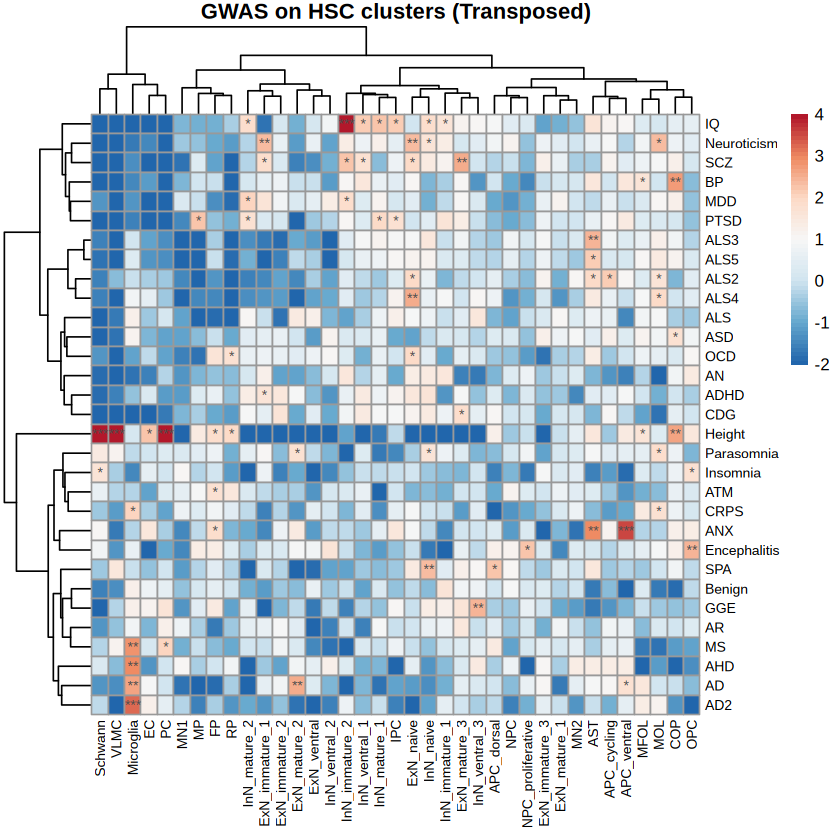

In [17]:
# 1. Transpose matrix and annotation
mat_t <- t(mat)
anno_t <- t(anno)

# 2. Plot
p <- pheatmap(mat_t,
         # Reuse predefined colors and breaks
         color = colorRampPalette(rev(brewer.pal(n = 7, name = "RdBu")))(60),
         breaks = seq(-2, 4, 0.1),
         
         fontsize_row = 8,
         fontsize_col = 8,
         
         # Use transposed annotation matrix
         display_numbers = anno_t,
         fontsize_number = 8,
         
         # Labels are auto-generated from row/column names of mat_t; or set manually by swapping below:
         labels_col = rownames(mat), # Original row names are now column names
         labels_row = colnames(mat), # Original column names are now row names
         
         # Key step: swap clustering objects
         # Original row dendrogram (hclust_rows) now applies to columns
         cluster_cols = hclust_rows, 
         # Original column dendrogram (hclust_cols) now applies to rows
         cluster_rows = hclust_cols,
         
         angle_col = 90,
         main = "GWAS on HSC clusters (Transposed)"
         )

In [17]:
pdf("hsc.ldsc.heatmap.pdf", width = 12, height = 6, onefile = FALSE)
grid::grid.draw(p$gtable)  # Draw gtable object directly
dev.off()

pdf 
  2